In [101]:
# Cell 1 — Import libraries

# Data manipulation
import pandas as pd
import numpy as np

# Machine learning
from xgboost import XGBRegressor

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [102]:
# Cell 2 — Load the dataset

df = pd.read_csv("../data/bakery_data.csv")

# Convert Date to proper datetime format
df["Date"] = pd.to_datetime(df["Date"])

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (7310, 18)


,Date,Product,Base_Price_LKR,Units_Produced,Units_Sold,Leftover,Day_of_Week,Month,Season,Is_Weekend,Temperature_C,Rainfall_mm,Weather_Code,Weather_Condition,Is_Holiday,Holiday_Name,Day_Before_Holiday,Day_After_Holiday
0,2024-01-01,Chicken Bun,130,54,49,5,Monday,1,Northeast Monsoon,False,23.5,11.8,63,Rain,False,NaN,False,False
1,2024-01-01,Chicken Pastry,180,69,66,3,Monday,1,Northeast Monsoon,False,23.5,11.8,63,Rain,False,NaN,False,False
2,2024-01-01,Chicken Samosa,90,63,58,5,Monday,1,Northeast Monsoon,False,23.5,11.8,63,Rain,False,NaN,False,False
3,2024-01-01,Cream Bun,120,39,35,4,Monday,1,Northeast Monsoon,False,23.5,11.8,63,Rain,False,NaN,False,False
4,2024-01-01,Egg Roll,100,38,37,1,Monday,1,Northeast Monsoon,False,23.5,11.8,63,Rain,False,NaN,False,False


In [103]:
# Cell 3 — Check dataset structure

print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Columns:
['Date', 'Product', 'Base_Price_LKR', 'Units_Produced', 'Units_Sold', 'Leftover', 'Day_of_Week', 'Month', 'Season', 'Is_Weekend', 'Temperature_C', 'Rainfall_mm', 'Weather_Code', 'Weather_Condition', 'Is_Holiday', 'Holiday_Name', 'Day_Before_Holiday', 'Day_After_Holiday']

Data types:
Date                  datetime64[us]
Product                          str
Base_Price_LKR                 int64
Units_Produced                 int64
Units_Sold                     int64
Leftover                       int64
Day_of_Week                      str
Month                          int64
Season                           str
Is_Weekend                      bool
Temperature_C                float64
Rainfall_mm                  float64
Weather_Code                   int64
Weather_Condition                str
Is_Holiday                      bool
Holiday_Name                     str
Day_Before_Holiday              bool
Day_After_Holiday               bool
dtype: object


In [104]:
# Cell 4 — Check for missing values

missing_values = df.isnull().sum()

print("Missing values by column:")
print(missing_values[missing_values > 0])

Missing values by column:
Holiday_Name    6790
dtype: int64


In [105]:
# Cell 5 — Define target and features

target = "Units_Sold"

features = [
    "Product",
    "Day_of_Week",
    "Month",
    "Season",
    "Is_Weekend",
    "Temperature_C",
    "Rainfall_mm",
    "Weather_Condition",
    "Is_Holiday",
    "Day_Before_Holiday",
    "Day_After_Holiday",
    "Base_Price_LKR"
]

X = df[features].copy()
y = df[target].copy()

print("Target:", target)
print("\nFeatures:")
for feature in features:
    print("-", feature)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Target: Units_Sold

Features:
- Product
- Day_of_Week
- Month
- Season
- Is_Weekend
- Temperature_C
- Rainfall_mm
- Weather_Condition
- Is_Holiday
- Day_Before_Holiday
- Day_After_Holiday
- Base_Price_LKR

X shape: (7310, 12)
y shape: (7310,)


In [106]:
# Cell 6 — Inspect selected features and target

print("Feature data:")
display(X.head())

print("\nTarget data:")
display(y.head())

Feature data:


,Product,Day_of_Week,Month,Season,Is_Weekend,Temperature_C,Rainfall_mm,Weather_Condition,Is_Holiday,Day_Before_Holiday,Day_After_Holiday,Base_Price_LKR
0,Chicken Bun,Monday,1,Northeast Monsoon,False,23.5,11.8,Rain,False,False,False,130
1,Chicken Pastry,Monday,1,Northeast Monsoon,False,23.5,11.8,Rain,False,False,False,180
2,Chicken Samosa,Monday,1,Northeast Monsoon,False,23.5,11.8,Rain,False,False,False,90
3,Cream Bun,Monday,1,Northeast Monsoon,False,23.5,11.8,Rain,False,False,False,120
4,Egg Roll,Monday,1,Northeast Monsoon,False,23.5,11.8,Rain,False,False,False,100



Target data:


0    49
1    66
2    58
3    35
4    37
Name: Units_Sold, dtype: int64

In [107]:
# Cell 7 — Inspect target distribution

print("Target statistics:")
print(y.describe())

print("\nMinimum Units Sold:", y.min())
print("Maximum Units Sold:", y.max())

Target statistics:
count    7310.000000
mean       57.958687
std        14.581110
min        25.000000
25%        48.000000
50%        56.000000
75%        66.000000
max       131.000000
Name: Units_Sold, dtype: float64

Minimum Units Sold: 25
Maximum Units Sold: 131


In [108]:
# Cell 8 — Sort data chronologically

df = df.sort_values(["Date", "Product"]).reset_index(drop=True)

print("First date:", df["Date"].min().date())
print("Last date:", df["Date"].max().date())

First date: 2024-01-01
Last date: 2025-12-31


In [109]:
# Cell 9 — Create chronological train/test date boundary

unique_dates = df["Date"].sort_values().unique()

split_index = int(len(unique_dates) * 0.80)

train_end_date = unique_dates[split_index - 1]
test_start_date = unique_dates[split_index]

print("Training period:")
print(df["Date"].min().date(), "to", pd.Timestamp(train_end_date).date())

print("\nTesting period:")
print(pd.Timestamp(test_start_date).date(), "to", df["Date"].max().date())

Training period:
2024-01-01 to 2025-08-06

Testing period:
2025-08-07 to 2025-12-31


In [110]:
# Cell 10 — Create chronological train/test sets

train_mask = df["Date"] <= train_end_date
test_mask = df["Date"] >= test_start_date

X_train = df.loc[train_mask, features].copy()
X_test = df.loc[test_mask, features].copy()

y_train = df.loc[train_mask, target].copy()
y_test = df.loc[test_mask, target].copy()

print("Training data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nTraining dates:")
print(df.loc[train_mask, "Date"].min().date(), "to", df.loc[train_mask, "Date"].max().date())

print("\nTesting dates:")
print(df.loc[test_mask, "Date"].min().date(), "to", df.loc[test_mask, "Date"].max().date())

Training data:
X_train: (5840, 12)
y_train: (5840,)

Testing data:
X_test: (1470, 12)
y_test: (1470,)

Training dates:
2024-01-01 to 2025-08-06

Testing dates:
2025-08-07 to 2025-12-31


In [111]:
# Cell 11 — Define categorical and numerical features

categorical_features = [
    "Product",
    "Day_of_Week",
    "Season",
    "Weather_Condition"
]

numerical_features = [
    "Month",
    "Is_Weekend",
    "Temperature_C",
    "Rainfall_mm",
    "Is_Holiday",
    "Day_Before_Holiday",
    "Day_After_Holiday",
    "Base_Price_LKR"
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['Product', 'Day_of_Week', 'Season', 'Weather_Condition']

Numerical features:
['Month', 'Is_Weekend', 'Temperature_C', 'Rainfall_mm', 'Is_Holiday', 'Day_Before_Holiday', 'Day_After_Holiday', 'Base_Price_LKR']


In [112]:
# Cell 12 — Build preprocessing pipeline

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [113]:
# Cell 13 — Fit and apply preprocessing

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed successfully.")

print("\nOriginal training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("\nOriginal testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Preprocessing completed successfully.

Original training shape: (5840, 12)
Processed training shape: (5840, 33)

Original testing shape: (1470, 12)
Processed testing shape: (1470, 33)


In [114]:
# Cell 14 — Train the baseline XGBoost model

baseline_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    objective="reg:squarederror"
)

baseline_model.fit(
    X_train_processed,
    y_train
)

print("Baseline XGBoost model trained successfully.")

Baseline XGBoost model trained successfully.


In [115]:
# Cell 15 — Evaluate the baseline model

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Make predictions on the test period
y_pred_baseline = baseline_model.predict(X_test_processed)

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred_baseline)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

# Calculate WAPE
wape = np.sum(np.abs(y_test - y_pred_baseline)) / np.sum(y_test)

print("Baseline Model Performance")
print("--------------------------")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"WAPE: {wape:.2%}")

Baseline Model Performance
--------------------------
MAE:  3.88
RMSE: 5.08
WAPE: 6.66%


In [116]:
# Cell 16 — Set up hyperparameter search

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

# Time-aware cross-validation
tscv = TimeSeriesSplit(n_splits=4)

# Hyperparameter ranges to explore
param_distributions = {
    "n_estimators": [100, 200, 300, 400, 500, 600],
    "learning_rate": [0.01, 0.03, 0.05, 0.07, 0.1],
    "max_depth": [3, 4, 5, 6, 7, 8],
    "min_child_weight": [1, 3, 5, 7],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.2, 0.3]
}

print("Time-series cross-validation configured.")
print("Hyperparameter search space created.")

Time-series cross-validation configured.
Hyperparameter search space created.


In [117]:
# Cell 17 — Run hyperparameter search

base_xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(
    X_train_processed,
    y_train
)

print("\nHyperparameter search completed.")

Fitting 4 folds for each of 30 candidates, totalling 120 fits

Hyperparameter search completed.


In [118]:
# Cell 18 — Display the best hyperparameters

print("Best hyperparameters:")
print("---------------------")

for parameter, value in random_search.best_params_.items():
    print(f"{parameter}: {value}")

print("\nBest cross-validation MAE:")
print(f"{-random_search.best_score_:.4f}")

Best hyperparameters:
---------------------
subsample: 0.7
n_estimators: 600
min_child_weight: 7
max_depth: 5
learning_rate: 0.03
gamma: 0
colsample_bytree: 0.7

Best cross-validation MAE:
4.4729


In [119]:
# Cell 20 — Evaluate the tuned model

y_pred_tuned = tuned_model.predict(X_test_processed)

# Calculate metrics
tuned_mae = mean_absolute_error(y_test, y_pred_tuned)

tuned_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_tuned)
)

tuned_wape = (
    np.sum(np.abs(y_test - y_pred_tuned))
    / np.sum(y_test)
)

print("Tuned Model Performance")
print("-----------------------")
print(f"MAE:  {tuned_mae:.2f}")
print(f"RMSE: {tuned_rmse:.2f}")
print(f"WAPE: {tuned_wape:.2%}")

Tuned Model Performance
-----------------------
MAE:  3.73
RMSE: 4.89
WAPE: 6.40%


In [120]:
# Cell 21 — Compare baseline and tuned models

model_comparison = pd.DataFrame({
    "Model": ["Baseline XGBoost", "Tuned XGBoost"],
    "MAE": [mae, tuned_mae],
    "RMSE": [rmse, tuned_rmse],
    "WAPE": [wape, tuned_wape]
})

model_comparison

,Model,MAE,RMSE,WAPE
0,Baseline XGBoost,3.884390,5.077151,0.066633
1,Tuned XGBoost,3.728961,4.891513,0.063967


In [121]:
# Cell 22 — Inspect actual vs predicted demand

prediction_results = pd.DataFrame({"Actual": y_test.values, "Predicted": y_pred_tuned})

prediction_results["Error"] = prediction_results["Actual"] - prediction_results["Predicted"]


prediction_results["Absolute_Error"] = prediction_results["Error"].abs()

prediction_results.head(20)

,Actual,Predicted,Error,Absolute_Error
0,66,60.950874,5.049126,5.049126
1,83,82.155609,0.844391,0.844391
2,64,63.093781,0.906219,0.906219
3,47,44.242222,2.757778,2.757778
4,48,56.305515,-8.305515,8.305515
5,62,67.665764,-5.665764,5.665764
6,58,50.465843,7.534157,7.534157
7,41,39.194958,1.805042,1.805042
8,52,55.158737,-3.158737,3.158737
9,51,51.627869,-0.627869,0.627869


In [122]:
# Cell 23 — Evaluate model performance by product

test_results = df.loc[test_mask, ["Date", "Product", "Units_Sold"]].copy()

test_results["Predicted"] = y_pred_tuned
test_results["Absolute_Error"] = (
    test_results["Units_Sold"] - test_results["Predicted"]
).abs()

product_performance = (
    test_results
    .groupby("Product")
    .agg(
        MAE=("Absolute_Error", "mean"),
        Actual_Average=("Units_Sold", "mean"),
        Predicted_Average=("Predicted", "mean")
    )
    .sort_values("MAE")
)

product_performance

,MAE,Actual_Average,Predicted_Average
Product,,,
Mini Pizza,2.494424,41.081633,41.253136
Cream Bun,3.098022,45.238095,45.406254
Fish Patty,3.178061,51.380952,51.534817
Vegetable Roti,3.320527,53.659864,53.810940
Egg Roll,3.400064,56.414966,56.758190
Chicken Bun,3.765563,61.224490,60.876434
Chicken Samosa,3.840677,64.503401,64.899765
Sausage Bun,3.874029,55.843537,55.715603
Fish Bun,4.429752,70.095238,69.555801


In [123]:
# Cell 24 — Check prediction bias by product

test_results["Error"] = (
    test_results["Units_Sold"] - test_results["Predicted"]
)

product_bias = (
    test_results
    .groupby("Product")["Error"]
    .mean()
    .sort_values()
)

print("Average prediction error by product:")
print(product_bias)

Average prediction error by product:
Product
Chicken Pastry   -0.786825
Chicken Samosa   -0.396367
Egg Roll         -0.343228
Mini Pizza       -0.171502
Cream Bun        -0.168159
Fish Patty       -0.153864
Vegetable Roti   -0.151075
Sausage Bun       0.127936
Chicken Bun       0.348055
Fish Bun          0.539436
Name: Error, dtype: float64


In [124]:
# Cell 25 — Check overall prediction bias

overall_bias = test_results["Error"].mean()

print("Overall average prediction error:", round(overall_bias, 4))

if overall_bias > 0:
    print("The model slightly underpredicts overall.")
elif overall_bias < 0:
    print("The model slightly overpredicts overall.")
else:
    print("The model has no overall prediction bias.")

Overall average prediction error: -0.1156
The model slightly overpredicts overall.


In [125]:
# Cell 26 — Analyze prediction error distribution

print("Prediction error statistics:")
print(test_results["Error"].describe())

print("\nMean error:", round(test_results["Error"].mean(), 4))
print("Median error:", round(test_results["Error"].median(), 4))
print("Minimum error:", round(test_results["Error"].min(), 4))
print("Maximum error:", round(test_results["Error"].max(), 4))

Prediction error statistics:
count    1470.000000
mean       -0.115559
std         4.891812
min       -17.789108
25%        -3.076764
50%        -0.298000
75%         2.764826
max        22.761765
Name: Error, dtype: float64

Mean error: -0.1156
Median error: -0.298
Minimum error: -17.7891
Maximum error: 22.7618


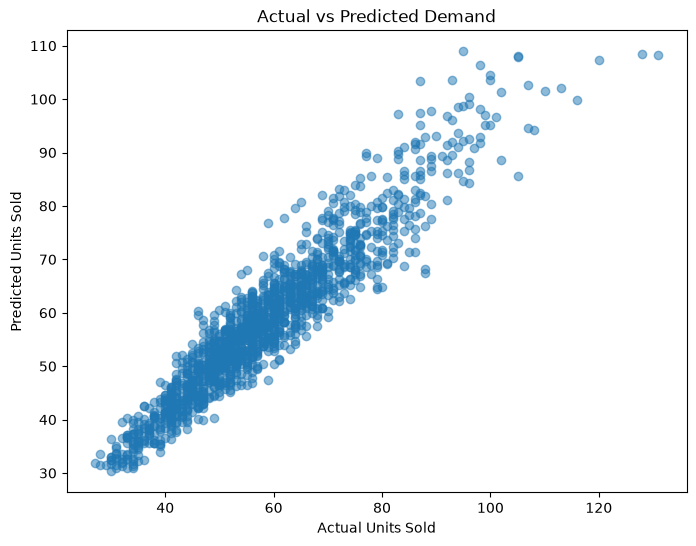

In [126]:
# Cell 27 — Plot actual vs predicted demand

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_tuned,
    alpha=0.5
)

plt.xlabel("Actual Units Sold")
plt.ylabel("Predicted Units Sold")
plt.title("Actual vs Predicted Demand")

plt.show()

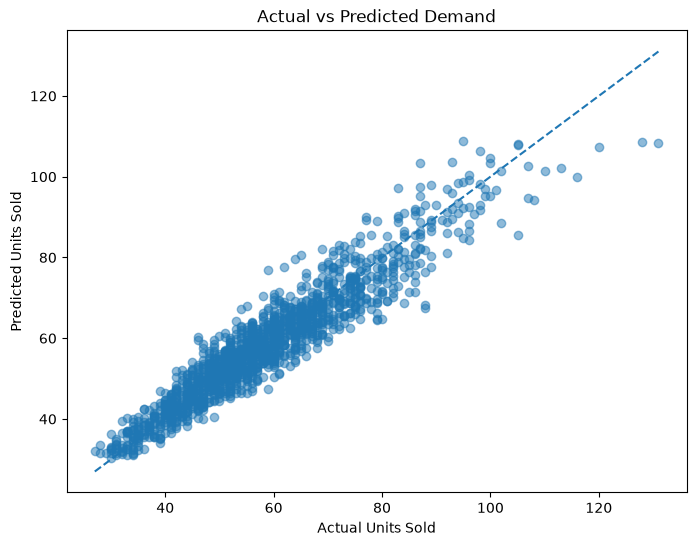

In [127]:
# Cell 28 — Add the ideal prediction line

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_tuned,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Units Sold")
plt.ylabel("Predicted Units Sold")
plt.title("Actual vs Predicted Demand")

plt.show()

In [128]:
# Cell 29 — Get feature importance

feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": tuned_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
1,categorical__Product_Chicken Pastry,0.321714
7,categorical__Product_Mini Pizza,0.141375
5,categorical__Product_Fish Bun,0.098912
3,categorical__Product_Cream Bun,0.093107
24,categorical__Weather_Condition_Rain,0.071620
2,categorical__Product_Chicken Samosa,0.045715
32,numerical__Base_Price_LKR,0.034429
6,categorical__Product_Fish Patty,0.027228
26,numerical__Is_Weekend,0.025645
0,categorical__Product_Chicken Bun,0.024990


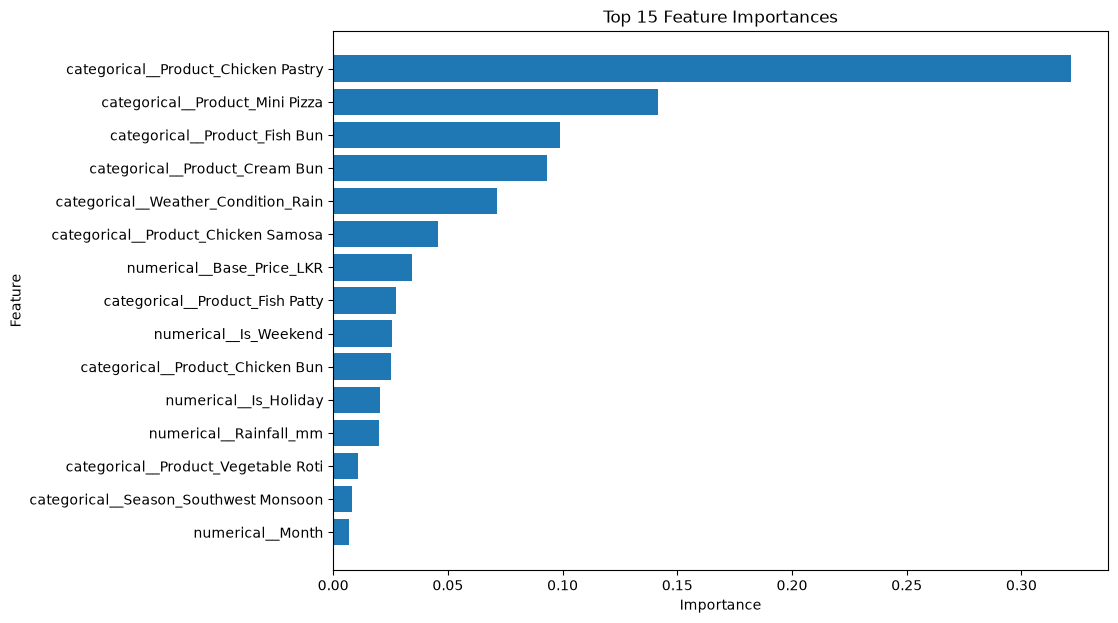

In [129]:
# Cell 30 — Plot top feature importance

top_features = feature_importance.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances")

plt.show()

In [130]:
# Cell 31 — Build the final model pipeline

from sklearn.pipeline import Pipeline

final_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            XGBRegressor(
                **random_search.best_params_,
                objective="reg:squarederror",
                random_state=42
            )
        )
    ]
)

print("Final model pipeline created successfully.")

Final model pipeline created successfully.


In [131]:
# Cell 32 — Train the final model pipeline

final_pipeline.fit(X_train, y_train)

print("Final model pipeline trained successfully.")

Final model pipeline trained successfully.


In [132]:
# Cell 33 — Evaluate the final pipeline

y_pred_final = final_pipeline.predict(X_test)

final_mae = mean_absolute_error(y_test, y_pred_final)

final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))

final_wape = (np.sum(np.abs(y_test - y_pred_final))/ np.sum(y_test))

print("Final Pipeline Performance")
print("--------------------------")
print(f"MAE:  {final_mae:.2f}")
print(f"RMSE: {final_rmse:.2f}")
print(f"WAPE: {final_wape:.2%}")

Final Pipeline Performance
--------------------------
MAE:  3.73
RMSE: 4.89
WAPE: 6.40%


In [133]:
# Cell 35 — Verify the saved model

import os

print("Model file exists:", os.path.exists(model_path))

print("Model file size:", os.path.getsize(model_path), "bytes")

Model file exists: True
Model file size: 1578323 bytes


In [134]:
# Cell 36 — Load the saved model

loaded_model = joblib.load(model_path)

print("Saved model loaded successfully.")
print("Model type:", type(loaded_model))

Saved model loaded successfully.
Model type: <class 'sklearn.pipeline.Pipeline'>


In [135]:
# Cell 37 — Test the loaded model

y_pred_loaded = loaded_model.predict(X_test)

loaded_mae = mean_absolute_error(y_test, y_pred_loaded)

loaded_rmse = np.sqrt(mean_squared_error(y_test, y_pred_loaded))

loaded_wape = (np.sum(np.abs(y_test - y_pred_loaded)) / np.sum(y_test))

print("Loaded Model Performance")
print("------------------------")
print(f"MAE:  {loaded_mae:.2f}")
print(f"RMSE: {loaded_rmse:.2f}")
print(f"WAPE: {loaded_wape:.2%}")

Loaded Model Performance
------------------------
MAE:  3.88
RMSE: 5.09
WAPE: 6.65%


In [136]:
# Cell 38 — Final model summary

print("Final Model Summary")
print("-------------------")
print("Model: XGBoost Regressor")
print("Target: Units_Sold")
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Features:", len(features))
print(f"MAE: {loaded_mae:.2f}")
print(f"RMSE: {loaded_rmse:.2f}")
print(f"WAPE: {loaded_wape:.2%}")
print("Model saved to:", model_path)

Final Model Summary
-------------------
Model: XGBoost Regressor
Target: Units_Sold
Training rows: 5840
Testing rows: 1470
Features: 12
MAE: 3.88
RMSE: 5.09
WAPE: 6.65%
Model saved to: ../models/demand_model.pkl


In [137]:
# Cell 39 — Record final hyperparameters

print("Final XGBoost Hyperparameters")
print("----------------------------")

for parameter, value in random_search.best_params_.items():
    print(f"{parameter}: {value}")

Final XGBoost Hyperparameters
----------------------------
subsample: 0.7
n_estimators: 600
min_child_weight: 7
max_depth: 5
learning_rate: 0.03
gamma: 0
colsample_bytree: 0.7


In [138]:
# Cell 40 — Final model conclusion

print("MODEL DEVELOPMENT COMPLETE")
print("--------------------------")
print("Final model: XGBoost Regressor")
print("Target: Units_Sold")
print("Features used:", len(features))
print(f"MAE: {final_mae:.2f}")
print(f"RMSE: {final_rmse:.2f}")
print(f"WAPE: {final_wape:.2%}")
print("Saved model: ../models/demand_model.pkl")
print("Model is ready for deployment.")

MODEL DEVELOPMENT COMPLETE
--------------------------
Final model: XGBoost Regressor
Target: Units_Sold
Features used: 12
MAE: 3.73
RMSE: 4.89
WAPE: 6.40%
Saved model: ../models/demand_model.pkl
Model is ready for deployment.
